In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import numpy as np

In [7]:
# load prefill model
MODEL_DIR = "/export2/obasit/ClusterLevelServing/DistServe/simdistserve/estimators/tree_models/"
pre = ort.InferenceSession(MODEL_DIR + "/prefill_model_latency.onnx")
dec = ort.InferenceSession(MODEL_DIR + "/decode_model_latency.onnx")
pre_p = ort.InferenceSession(MODEL_DIR + "/prefill_model_power.onnx")
dec_p = ort.InferenceSession(MODEL_DIR + "/decode_model_power.onnx")


def infer(model, tokens, tp, freq):
    FEATURE_COLS = [
        "batch_size",
        "input_len_sum",
        "input_len_mean",
        "input_len_std",
        "tp_degree",
        "freq_mhz",
        "model"
    ]

    X = pd.DataFrame([{
        "batch_size": len(tokens),
        "input_len_sum": sum(tokens),
        "input_len_mean": float(np.mean(tokens)),
        "input_len_std": float(np.std(tokens)),
        "tp_degree": tp,
        "freq_mhz": freq,
        "model": "Llama-3.3-70B-Instruct"
    }], columns=FEATURE_COLS)


    input_feed = {}
    for col in FEATURE_COLS:
        val = X[col].values.reshape(-1, 1)
        if X[col].dtype == object or col == "model":
            input_feed[col] = val.astype(str)
        else:
            input_feed[col] = val.astype("float32")

    inputs = input_feed
    outputs = model.run(None, inputs)
    return outputs


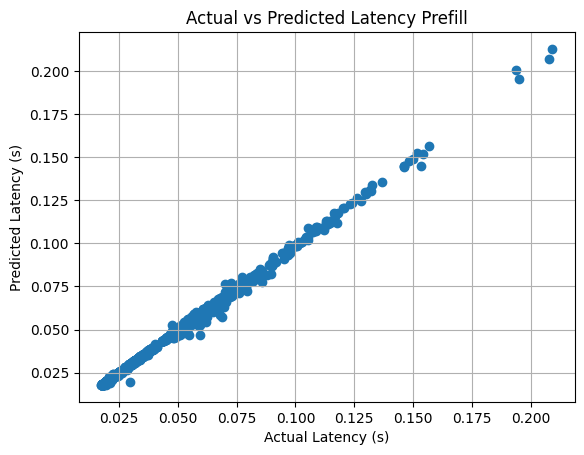

In [ ]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps30_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/prefill_0_Oct13034118/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer(pre, tokens, 4, 1830)[0][0][0] for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

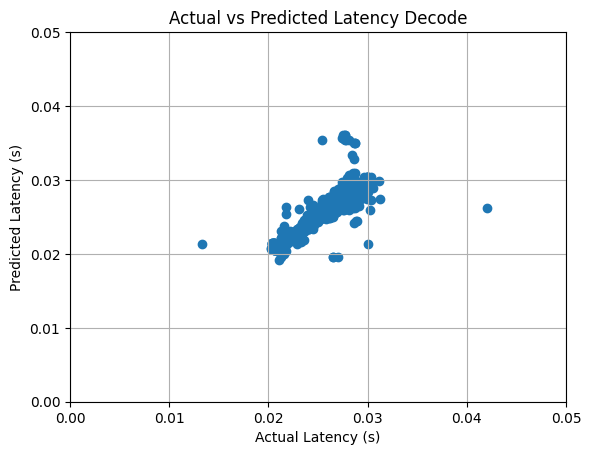

In [9]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps22_freq1080/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/decode_4_Oct13040955/engine_0.csv"
df_decode = pd.read_csv(path)


df_decode['request_ids_iter_tbt_evald'] = df_decode['request_ids_iter_tbt'].apply(eval)
df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
num_computed_dict = {}
num_computed_tokens_list = [[] for _ in range(len(df_decode))]
#first get num_computed_tokens for each req in each row
for row in df_decode.itertuples():
    if len(row.request_ids_iter_tbt_evald) == 0:
        continue
    else:
        for ID, in_len in zip(row.request_ids_iter_tbt_evald, row.num_prompt_tokens_reqs_evald):
            if ID not in num_computed_dict:
                num_computed_dict[ID] = in_len + 1
            else:
                num_computed_dict[ID] = num_computed_dict[ID] + 1
        num_computed_tokens_list[row.Index] = [num_computed_dict[ID] for ID in row.request_ids_iter_tbt_evald]
df_decode['num_computed_tokens_reqs_evald'] = num_computed_tokens_list

token_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['num_computed_tokens_reqs_evald'].tolist()
latency_lists = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['iter_lat'].tolist()

predicted_latencies = [infer(dec, tokens, 4, 1080)[0][0][0] for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Decode")
plt.grid(True)
plt.xlim(0, 0.05)
plt.ylim(0, 0.05)
plt.show()

In [4]:
i = np.argmax(latency_lists)
print(i)
print(predicted_latencies[i])
print(latency_lists[i])
print(len(token_lists[i]), np.sum(token_lists[i]), np.mean(token_lists[i]), np.std(token_lists[i]))

now_list = df_decode[df_decode['iter_lat'].notna() & df_decode['num_computed_tokens_reqs_evald'].notna()]['now'].tolist()
print(now_list[i])

2208
0.023063168
0.04200943900013954
87 26618 305.95402298850576 310.361780294745
1760328796.868327


In [ ]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps30_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/prefill_0_Oct13034118/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer(pre_p, tokens, 4, 1980)[0][0][0] for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Power Prefill")
plt.grid(True)
plt.show()